# Лабораторная работа 5. Метод опорных векторов и деревья решений в задачах классификации и регрессии

## Примерная структура блокнота для задания 2

### 1. Подготовка среды

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# Настройка стиля графиков
sns.set(style="whitegrid")

### 2. Генерация и визуализация наборов данных

Сгенерируйте набор данных для задачи классификаии

In [2]:
student_number = 20

X, y = make_classification(
    n_samples=500,
    n_features=4,
    n_informative=3,
    n_redundant=1,
    n_clusters_per_class=1,
    random_state=student_number
)

# Создание DataFrame для удобства
feature_names = [f"feature_{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Первые 5 строк данных:")
df.head()

Первые 5 строк данных:


,feature_0,feature_1,feature_2,feature_3,target
0,0.767757,2.086895,0.679723,1.211624,1
1,-0.923855,-0.836437,1.328336,1.979566,0
2,-0.993165,-1.317875,2.525123,2.048010,0
3,-0.695429,-1.151522,1.214537,0.840324,0
4,-0.692528,-0.682382,0.327425,1.085277,0


### 3. Разделение данных

Выполните разделение данных на обучающую и тестовую выборки:

In [3]:
# Ячейка 3: Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=student_number, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

Размер обучающей выборки: 400
Размер тестовой выборки: 100


### 4. Обучение дерева решений

4.1. Выполните обучение дерева решений с параметрами по умолчанию:

In [4]:
# Обучение дерева решений (по умолчанию)
clf_default = DecisionTreeClassifier(random_state=student_number)
clf_default.fit(X_train, y_train)

y_pred_default = clf_default.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)

print(f"Точность модели (по умолчанию): {acc_default:.4f}")
print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_default))

Точность модели (по умолчанию): 0.9400

Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        50
           1       0.92      0.96      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



4.2. Выполните обучение дерева с ограничением глубины:

In [5]:
# Обучение дерева с ограничением глубины
clf_depth = DecisionTreeClassifier(max_depth=3, random_state=student_number)
clf_depth.fit(X_train, y_train)

y_pred_depth = clf_depth.predict(X_test)
acc_depth = accuracy_score(y_test, y_pred_depth)

print(f"Точность модели (max_depth=3): {acc_depth:.4f}")
print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred_depth))

Точность модели (max_depth=3): 0.9400

Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        50
           1       0.98      0.90      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



### 5. Визуализация дерева

Пример визуализации дерева с ограничением глубины:

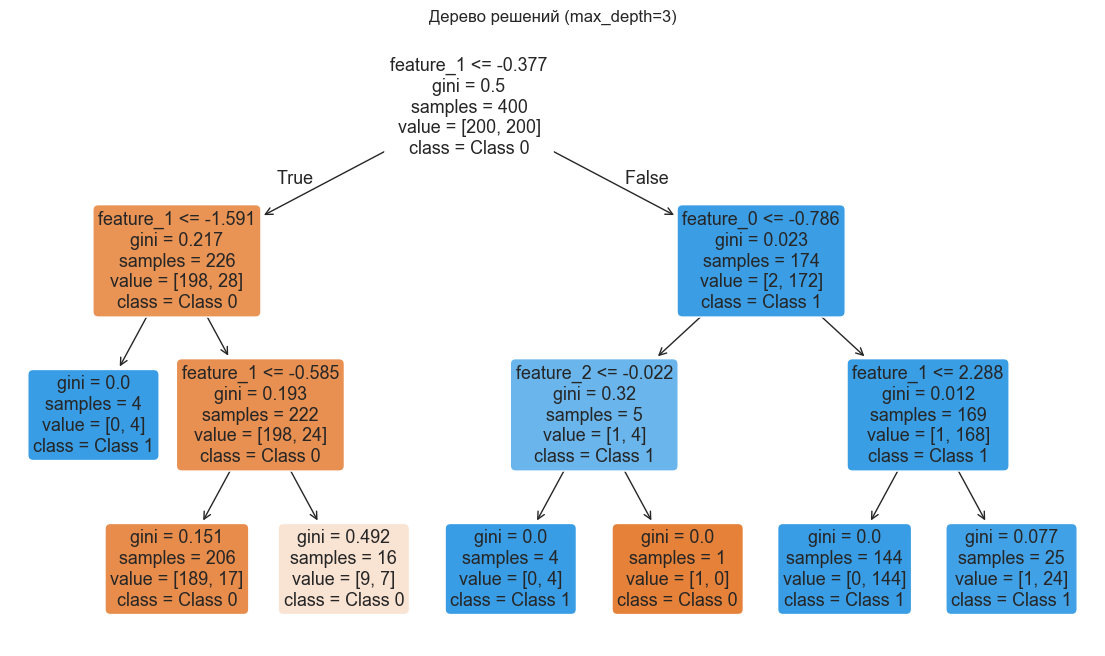

In [6]:
# Визуализация дерева с ограничением глубины
plt.figure(figsize=(14, 8))
plot_tree(
    clf_depth,
    feature_names=feature_names,
    class_names=['Class 0', 'Class 1'],
    filled=True,
    rounded=True,
)
plt.title("Дерево решений (max_depth=3)")
plt.show()

### 6. Сравнение и 

Выполните сравнение моделей с ограничением глубины и без:

In [7]:
print("Сравнение моделей:")
print(f"- Без ограничения глубины: точность = {acc_default:.4f}")
print(f"- С max_depth=3:           точность = {acc_depth:.4f}")

Сравнение моделей:
- Без ограничения глубины: точность = 0.9400
- С max_depth=3:           точность = 0.9400


### 7. Выводы

Добавьте ответы на вопросы и сформулируйте выводы по деревьям решений.

## Принцип работы

Дерево решений рекурсивно разделяет данные, выбирая признаки, которые лучше всего разделяют целевые переменные.

### Алгоритмы:

**ID3** (1986):
- Использует **прирост информации** на основе энтропии
- Только категориальные признаки
- Нет обработки переобучения

**C4.5** (1993):
- Улучшение ID3
- **Коэффициент усиления** вместо прироста информации
- Работает с непрерывными признаками
- Обрезка деревьев

**CART** (1984):
- Использует **индекс Джини**
- Строит бинарные деревья
- Регрессия и классификация